<h2 align="center">Box Plot (Seaborn)</h2>

In [1]:
# importing libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import ast

#load dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# cleaning the data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

c:\Users\mrpra\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# now we want to compare for 3 job titles
job_titles = ['Data Analyst','Data Engineer','Data Scientist']

# creating new dataframe for all job titles for india
US_df = df[(df['job_title_short'].isin (job_titles)) & (df['job_country']=='United States')].dropna(subset=['salary_year_avg']).copy()

# creating a list for job titles
job_list = [US_df[US_df['job_title_short']==job_name]['salary_year_avg'] for job_name in job_titles]

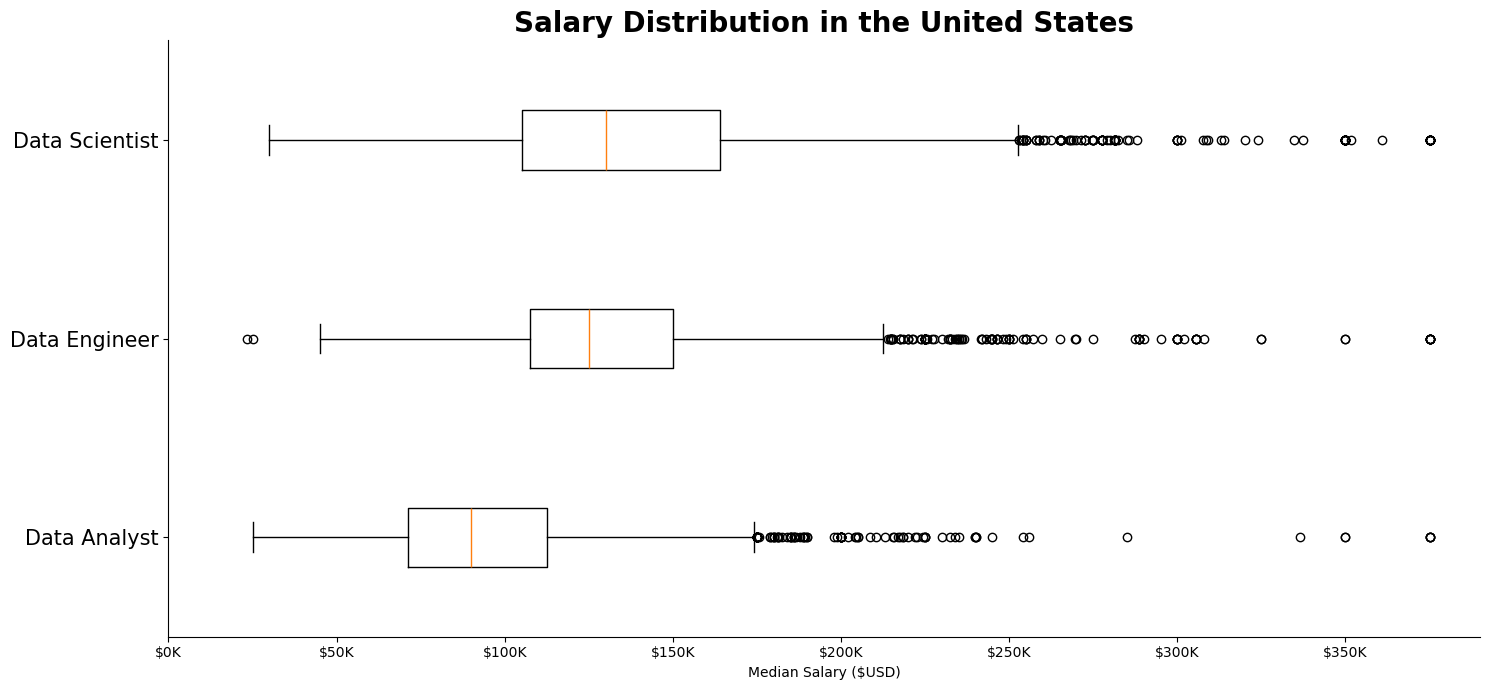

In [3]:
# library for mticker
import matplotlib.ticker as mticker

# lets plot this using matplotlib
plt.figure(figsize=(15, 7))
plt.boxplot(job_list,tick_labels=job_titles,vert=False,)

# lets format the plot
plt.title('Salary Distribution in the United States',fontsize=20,fontweight='bold')
plt.xlabel('Median Salary ($USD)')
plt.ylabel('')
plt.yticks(size=15)
plt.xlim(0,390000)
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


# remove extra borders
for spine in ['top','right']:
    plt.gca().spines[spine].set_visible(False)


plt.tight_layout()
plt.show()

# Using Seaborn instead

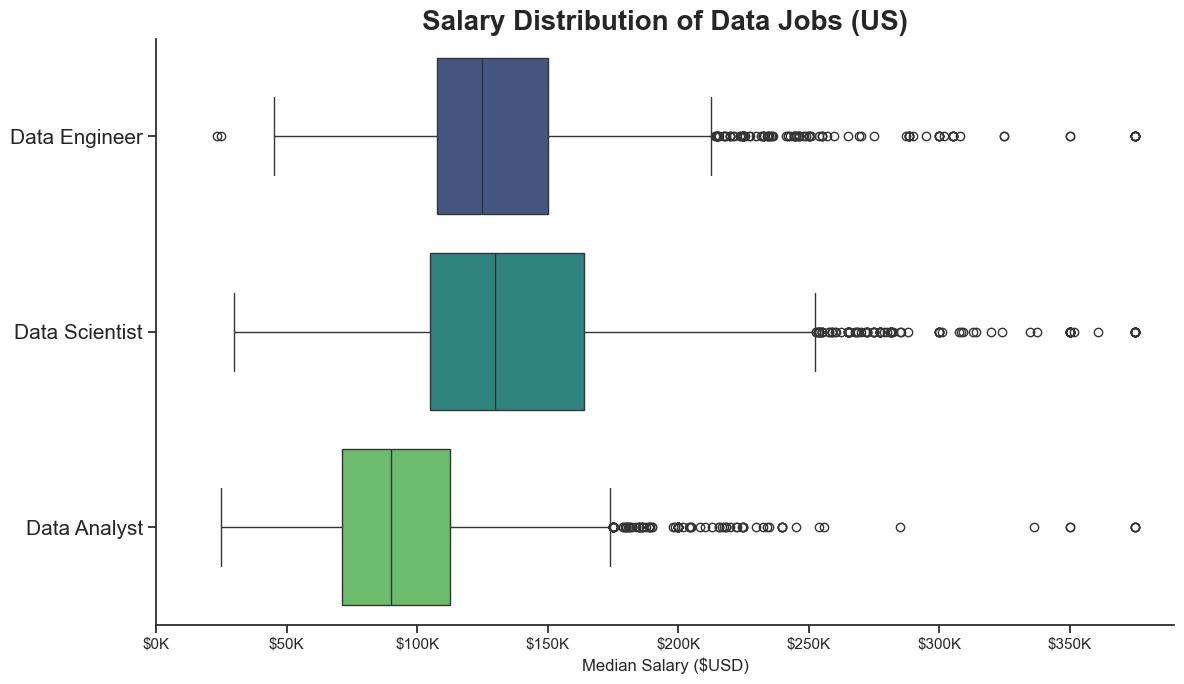

In [17]:
# library for mticker
from turtle import st

import matplotlib.ticker as mticker

# lets plot this using matplotlib
plt.figure(figsize=(12, 7))
# plt.boxplot(job_list,tick_labels=job_titles,vert=False,)
sns.set_theme(style='ticks')
sns.boxplot(data=US_df, x= 'salary_year_avg', y='job_title_short',hue="job_title_short",palette="viridis")

# lets format the plot
plt.title('Salary Distribution of Data Jobs (US)',fontsize=20,fontweight='bold')
plt.xlabel('Median Salary ($USD)')
plt.ylabel('')
plt.yticks(size=15)
plt.xlim(0,390000)
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


# remove extra borders
for spine in ['top','right']:
    plt.gca().spines[spine].set_visible(False)


plt.tight_layout()
plt.show()